# Malware detection

# 1. Import data and discover it

In [22]:
import pandas as pd

df = pd.read_csv("~/Documentation/PE_Header.csv")
class_names = ["Benign", "RedLineStealer", "Downloader", "RAT", "BankingTrojan", "SnakeKeyLogger", "Spyware"]
df.head()

,SHA256,Type,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,...,SizeOfImage,SizeOfHeaders,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes
0,dacbe8cb72dd746539792a50e84965fefef73feaa07b5d...,0,23117,144,3,0,4,0,65535,0,...,139264,4096,0,2,1344,1048576,1048576,4096,0,16
1,d3dc7512ce75db33b2c3063fa99245e9ca9fe3b086462f...,0,23117,144,3,0,4,0,65535,0,...,49152,512,0,2,34112,1048576,1048576,4096,0,16
2,b350fac81533f02981dc2176ed17163177d92d9405758e...,0,23117,144,3,0,4,0,65535,0,...,532480,512,0,2,34144,1048576,1048576,4096,0,16
3,dfee618043a47b7b09305df0ca460559d9f567ee246c7b...,0,23117,144,3,0,4,0,65535,0,...,1368064,4096,1366781,2,1024,1048576,1048576,4096,0,16
4,c7b2e4e4fb2fcc44c953673ff57c3d14bdf5d2008f35e9...,0,23117,144,3,0,4,0,65535,0,...,32768,512,64362,2,1344,1048576,1048576,4096,0,16


## 1.1 Discover data

In [23]:
df.isnull().sum()


SHA256                         0
Type                           0
e_magic                        0
e_cblp                         0
e_cp                           0
e_crlc                         0
e_cparhdr                      0
e_minalloc                     0
e_maxalloc                     0
e_ss                           0
e_sp                           0
e_csum                         0
e_ip                           0
e_cs                           0
e_lfarlc                       0
e_ovno                         0
e_oemid                        0
e_oeminfo                      0
e_lfanew                       0
Machine                        0
NumberOfSections               0
TimeDateStamp                  0
PointerToSymbolTable           0
NumberOfSymbols                0
SizeOfOptionalHeader           0
Characteristics                0
Magic                          0
MajorLinkerVersion             0
MinorLinkerVersion             0
SizeOfCode                     0
SizeOfInit

In [24]:
df.info(),df.columns

<class 'pandas.DataFrame'>
RangeIndex: 29807 entries, 0 to 29806
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   SHA256                       29807 non-null  str  
 1   Type                         29807 non-null  int64
 2   e_magic                      29807 non-null  int64
 3   e_cblp                       29807 non-null  int64
 4   e_cp                         29807 non-null  int64
 5   e_crlc                       29807 non-null  int64
 6   e_cparhdr                    29807 non-null  int64
 7   e_minalloc                   29807 non-null  int64
 8   e_maxalloc                   29807 non-null  int64
 9   e_ss                         29807 non-null  int64
 10  e_sp                         29807 non-null  int64
 11  e_csum                       29807 non-null  int64
 12  e_ip                         29807 non-null  int64
 13  e_cs                         29807 non-null  int64
 14  e

(None,
 Index(['SHA256', 'Type', 'e_magic', 'e_cblp', 'e_cp', 'e_crlc', 'e_cparhdr',
        'e_minalloc', 'e_maxalloc', 'e_ss', 'e_sp', 'e_csum', 'e_ip', 'e_cs',
        'e_lfarlc', 'e_ovno', 'e_oemid', 'e_oeminfo', 'e_lfanew', 'Machine',
        'NumberOfSections', 'TimeDateStamp', 'PointerToSymbolTable',
        'NumberOfSymbols', 'SizeOfOptionalHeader', 'Characteristics', 'Magic',
        'MajorLinkerVersion', 'MinorLinkerVersion', 'SizeOfCode',
        'SizeOfInitializedData', 'SizeOfUninitializedData',
        'AddressOfEntryPoint', 'BaseOfCode', 'ImageBase', 'SectionAlignment',
        'FileAlignment', 'MajorOperatingSystemVersion',
        'MinorOperatingSystemVersion', 'MajorImageVersion', 'MinorImageVersion',
        'MajorSubsystemVersion', 'MinorSubsystemVersion', 'Reserved1',
        'SizeOfImage', 'SizeOfHeaders', 'CheckSum', 'Subsystem',
        'DllCharacteristics', 'SizeOfStackReserve', 'SizeOfHeapReserve',
        'SizeOfHeapCommit', 'LoaderFlags', 'NumberOfRvaAndSize

In [25]:
df["Type"].value_counts()

Type
4    5104
1    5047
3    4973
2    4864
5    4236
6    3706
0    1877
Name: count, dtype: int64

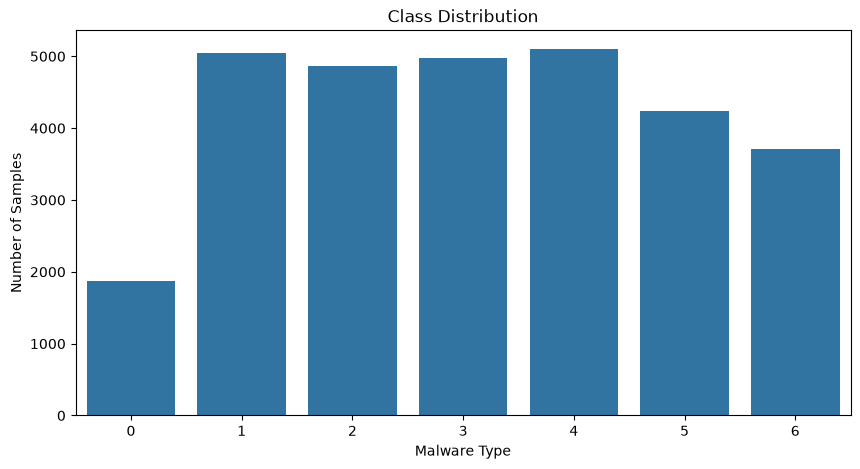

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Type"
)

plt.title("Class Distribution")
plt.xlabel("Malware Type")
plt.ylabel("Number of Samples")
plt.show()

In [27]:
df.describe()

,Type,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,...,SizeOfImage,SizeOfHeaders,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes
count,29807.000000,29807.0,29807.000000,29807.000000,29807.000000,29807.000000,29807.000000,29807.000000,29807.000000,29807.000000,...,2.980700e+04,29807.000000,2.980700e+04,29807.000000,29807.000000,2.980700e+04,2.980700e+04,29807.000000,29807.0,29807.000000
mean,3.137719,23117.0,251.805415,754.102593,404.025464,43.835576,354.468078,64788.852551,198.975778,378.190425,...,1.867389e+06,1452.845305,1.106016e+06,2.077901,23421.903177,1.090262e+06,1.063879e+06,4096.420136,0.0,15.991445
std,1.801958,0.0,1532.495681,6583.983720,3640.873340,1290.672177,3120.411120,6421.027707,1810.405076,2324.751433,...,6.605455e+06,1365.458901,4.201892e+07,0.268020,15721.665448,5.435179e+05,2.304633e+05,245.286161,0.0,0.101127
min,0.000000,23117.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.048000e+04,512.000000,0.000000e+00,2.000000,0.000000,0.000000e+00,8.850000e+02,0.000000,0.0,14.000000
25%,2.000000,23117.0,144.000000,3.000000,0.000000,4.000000,0.000000,65535.000000,0.000000,184.000000,...,2.457600e+05,512.000000,0.000000e+00,2.000000,0.000000,1.048576e+06,1.048576e+06,4096.000000,0.0,16.000000
50%,3.000000,23117.0,144.000000,3.000000,0.000000,4.000000,0.000000,65535.000000,0.000000,184.000000,...,4.997120e+05,1024.000000,0.000000e+00,2.000000,33024.000000,1.048576e+06,1.048576e+06,4096.000000,0.0,16.000000
75%,5.000000,23117.0,144.000000,3.000000,0.000000,4.000000,0.000000,65535.000000,0.000000,184.000000,...,9.441280e+05,1024.000000,3.386080e+05,2.000000,34112.000000,1.048576e+06,1.048576e+06,4096.000000,0.0,16.000000
max,6.000000,23117.0,64110.000000,62388.000000,63030.000000,64913.000000,57879.000000,65535.000000,59756.000000,64539.000000,...,1.225933e+08,8192.000000,3.885444e+09,3.000000,50496.000000,6.710886e+07,4.194304e+06,16384.000000,0.0,16.000000


In [28]:
len(df), df.isnull().sum()

(29807,
 SHA256                         0
 Type                           0
 e_magic                        0
 e_cblp                         0
 e_cp                           0
 e_crlc                         0
 e_cparhdr                      0
 e_minalloc                     0
 e_maxalloc                     0
 e_ss                           0
 e_sp                           0
 e_csum                         0
 e_ip                           0
 e_cs                           0
 e_lfarlc                       0
 e_ovno                         0
 e_oemid                        0
 e_oeminfo                      0
 e_lfanew                       0
 Machine                        0
 NumberOfSections               0
 TimeDateStamp                  0
 PointerToSymbolTable           0
 NumberOfSymbols                0
 SizeOfOptionalHeader           0
 Characteristics                0
 Magic                          0
 MajorLinkerVersion             0
 MinorLinkerVersion             0
 SizeO

In [29]:
df.nunique().sort_values()

e_magic                            1
LoaderFlags                        1
SizeOfOptionalHeader               2
Magic                              2
SectionAlignment                   2
Subsystem                          2
Machine                            2
NumberOfRvaAndSizes                3
MinorOperatingSystemVersion        4
MinorSubsystemVersion              4
SizeOfHeapCommit                   5
FileAlignment                      5
MajorSubsystemVersion              6
Type                               7
SizeOfHeapReserve                  7
MajorOperatingSystemVersion        8
Reserved1                          9
SizeOfHeaders                      9
MinorImageVersion                 14
SizeOfStackReserve                15
e_maxalloc                        21
e_crlc                            21
NumberOfSections                  22
e_minalloc                        22
e_cparhdr                         22
e_sp                              23
e_cp                              24
I

In [30]:
df.dtypes,df["Type"].value_counts(),df.duplicated().sum()

(SHA256                           str
 Type                           int64
 e_magic                        int64
 e_cblp                         int64
 e_cp                           int64
 e_crlc                         int64
 e_cparhdr                      int64
 e_minalloc                     int64
 e_maxalloc                     int64
 e_ss                           int64
 e_sp                           int64
 e_csum                         int64
 e_ip                           int64
 e_cs                           int64
 e_lfarlc                       int64
 e_ovno                         int64
 e_oemid                        int64
 e_oeminfo                      int64
 e_lfanew                       int64
 Machine                        int64
 NumberOfSections               int64
 TimeDateStamp                  int64
 PointerToSymbolTable           int64
 NumberOfSymbols                int64
 SizeOfOptionalHeader           int64
 Characteristics                int64
 Magic      

As I saw. This data is no missing data, so I have to choose label and feature for training process. 
In my opinion, I have to drop SHA256 and `Type`, and cho `Type` is a targer (label).
Because `SHA256` seem it just a identification for a file, It does not cover useful feature for training process

## 1.2 Split the data

In [31]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier

`df.describe()`, Except for columns **`Type`** which is the target. There are several columns we can drop for `X`:
* `SHA256`: it is just a file identifier and does not cover information useful for learning
* `e_magic`: The sample from *e_magic*'s column has the same value. It does not help model distinguish by malware
* `LoaderFlags`: This also the same case `e_magic`

In [32]:
X = df.drop(columns=["SHA256", "Type", "e_magic", "LoaderFlags"])
# #X = df.drop(columns=["SHA256","Type"])
y = df["Type"]
len(X), len(y)


(29807, 29807)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

len(X_train), len(X_test), len(y_train), len(y_test)

(23845, 5962, 23845, 5962)

I use a scaler for my values, although random forest is not sensitive to feature scaling. But I'm using this, because I'm trying some model.

In [34]:
# scaler = StandardScaler()
# scaler =RobustScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
# len(X_train), len(X_test)


# 2. Train model

## 2.1 Random Forest is a first model is choosed
Random Forest is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting. In Scikit‑learn, the Random Forest Classifier is widely used for classification tasks because it handles large datasets and handles nonlinear relationships well.



In [57]:
classifier = RandomForestClassifier(
	n_estimators=500, 
	random_state=42,
	criterion="log_loss", 
	n_jobs=-1,
	class_weight="balanced")


In [58]:
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

Metric which using to evaluate how model perform

In [59]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

# Do a func for calculation more easier
def calculate_metric(y_true, y_pred):

	accuracy = accuracy_score(y_true, y_pred)

	f1 = f1_score(y_true, y_pred,average='macro')

	cf = confusion_matrix(y_true, y_pred)
	precision = precision_score(y_true,y_pred,average="macro")

	recall = recall_score(y_true,y_pred,average="macro")

	return accuracy,f1,cf,precision,recall




In [60]:
results =[]
f1_results =[]
precision_results =[]
recall_results =[]

In [61]:
accuracy, f1, cf, precision, recall = calculate_metric(y_true=y_test, y_pred=y_pred)
results.append(accuracy)
f1_results.append(f1)
precision_results.append(precision)
recall_results.append(recall)
print(f'Accuracy: {accuracy:.4f}')

print(f'F1 scores: {f1:.4f}')

print(f'Confusion matrix: {cf}')

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

Accuracy: 0.8880
F1 scores: 0.8873
Confusion matrix: [[358   0   3   9   3   2   0]
 [  4 950   6  12  32   4   2]
 [  2   3 959   6   3   0   0]
 [ 14   4   3 836  16  73  49]
 [  4  34   2  22 914  21  24]
 [  2   3   0  16   6 651 169]
 [  1   4   0  16  10  84 626]]
Precision: 0.8867
Recall   : 0.8900


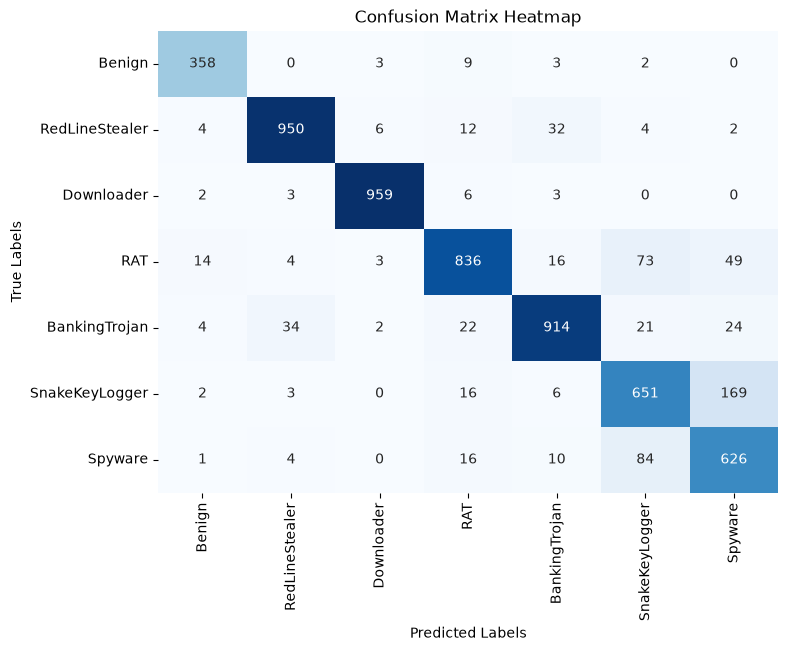

In [62]:
display_confusion_matrix(cf, class_names)

In [40]:
print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nFeature importance:")
print(
    pd.Series(
        classifier.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)
)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Train: (23845, 50)
Test : (5962, 50)

Feature importance:
TimeDateStamp                  0.186729
AddressOfEntryPoint            0.099209
SizeOfImage                    0.096483
SizeOfCode                     0.087201
SizeOfInitializedData          0.081559
CheckSum                       0.053849
DllCharacteristics             0.047419
MajorLinkerVersion             0.042400
Characteristics                0.038292
e_lfanew                       0.031710
BaseOfCode                     0.027201
SectionAlignment               0.025777
NumberOfSections               0.022558
SizeOfHeaders                  0.019980
MajorImageVersion              0.019263
FileAlignment                  0.013801
MinorLinkerVersion             0.012963
MajorSubsystemVersion          0.012157
SizeOfUninitializedData        0.011179
MajorOperatingSystemVersion    0.010684
Subsystem                      0.009292
Machine                        0.005230
SizeOfOptionalHeader           0.005054
Magic                 

In [42]:
def display_confusion_matrix (cf_val, classes):


	plt.figure(figsize=(8,6))

	sns.heatmap(cf_val, annot=True, 
					fmt='g', 
					cmap='Blues', 
					cbar=False, 
					xticklabels=classes, 
					yticklabels=classes)
	plt.title('Confusion Matrix Heatmap')
	plt.xlabel('Predicted Labels')
	plt.ylabel('True Labels')
	plt.show()

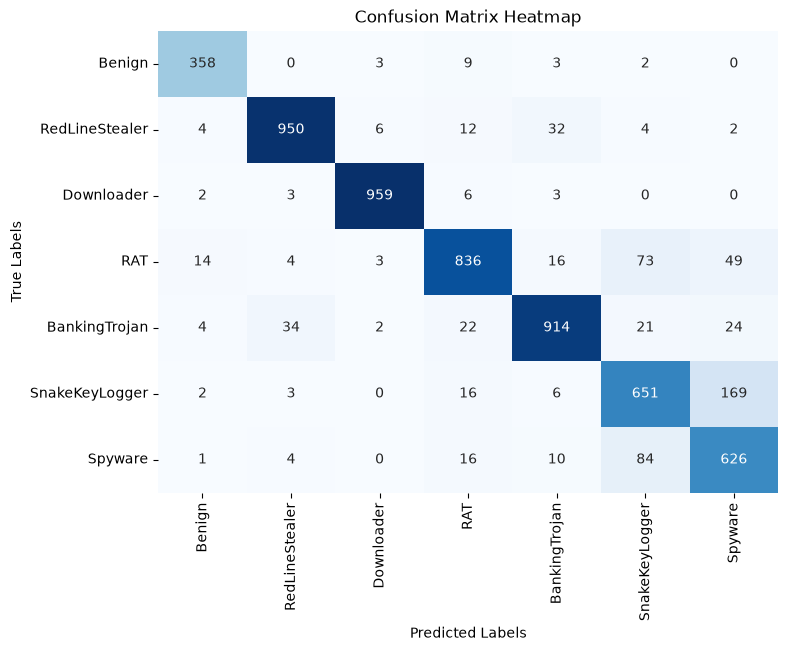

In [63]:
display_confusion_matrix(cf, class_names)

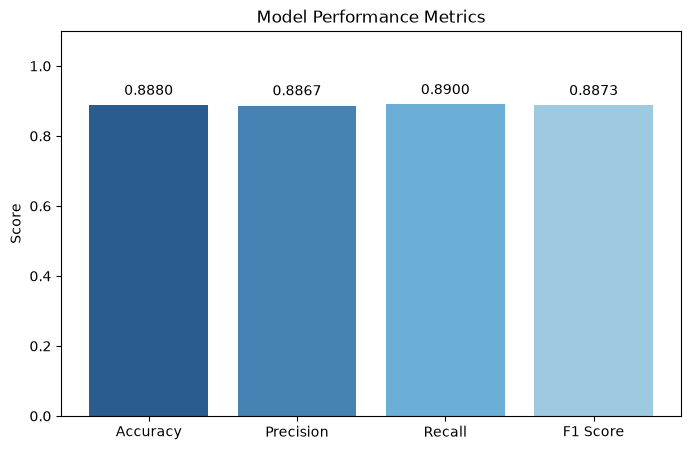

In [64]:
import matplotlib.pyplot as plt

metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
}

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics.keys(), metrics.values(), color=['#2b5c8f', '#4682b4', '#6baed6', '#9ecae1'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom')

plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Model Performance Metrics')
plt.show()

## 2.2 Try other model as XGBC

In [65]:
from xgboost import XGBClassifier

model_XGB = XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

model_XGB.fit(X_train, y_train)

y_pred_1 = model_XGB.predict(X_test)

In [66]:
accuracy, f1, cf, precision, recall = calculate_metric(y_true=y_test, y_pred=y_pred_1)
results.append(accuracy)
f1_results.append(f1)
precision_results.append(precision)
recall_results.append(recall)
print(f'Accuracy: {accuracy:.4f}')

print(f'F1 scores: {f1:.4f}')

print(f'Confusion matrix: {cf}')

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

Accuracy: 0.8881
F1 scores: 0.8884
Confusion matrix: [[359   1   2   9   2   2   0]
 [  3 946   2  14  37   5   3]
 [  2   2 958   7   4   0   0]
 [  5   5   4 850  21  68  42]
 [  3  36   2  21 928  13  18]
 [  1   7   0  24   5 651 159]
 [  1   6   0  17  14 100 603]]
Precision: 0.8885
Recall   : 0.8892


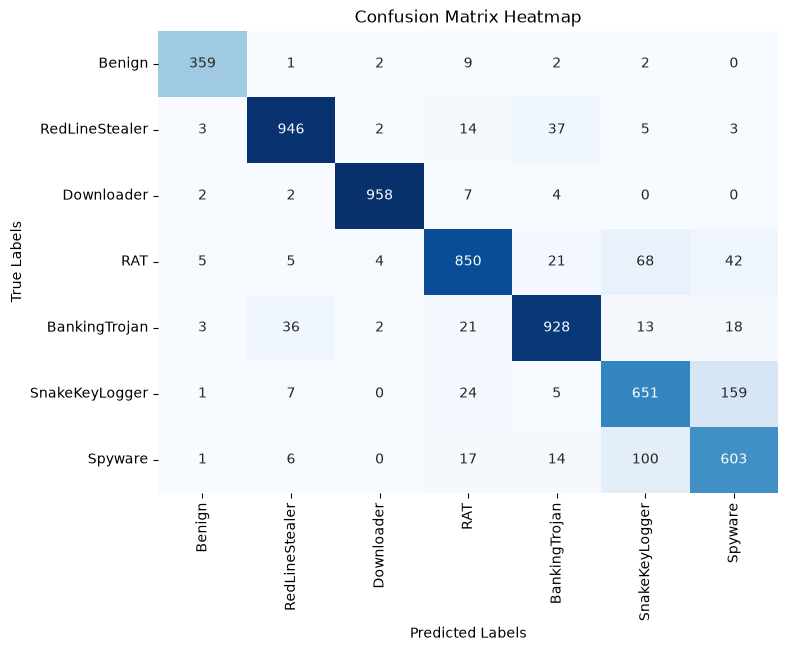

In [67]:
display_confusion_matrix(cf, class_names)

## 2.3 Try with CatBoostClassifier

In [68]:
from catboost import CatBoostClassifier

model_CatBoost = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

model_CatBoost.fit(X_train, y_train)

y_pred_2 = model_CatBoost.predict(X_test).ravel()

0:	learn: 0.6954078	total: 112ms	remaining: 1m 51s
100:	learn: 0.8429021	total: 5.25s	remaining: 46.8s
200:	learn: 0.8602642	total: 10.6s	remaining: 42s
300:	learn: 0.8743552	total: 16.1s	remaining: 37.4s
400:	learn: 0.8853848	total: 21.8s	remaining: 32.6s
500:	learn: 0.8933110	total: 28s	remaining: 27.9s
600:	learn: 0.9011113	total: 33.7s	remaining: 22.3s
700:	learn: 0.9063116	total: 39.1s	remaining: 16.7s
800:	learn: 0.9104634	total: 44.5s	remaining: 11.1s
900:	learn: 0.9150765	total: 50.4s	remaining: 5.54s
999:	learn: 0.9190606	total: 56.5s	remaining: 0us


In [69]:
accuracy, f1, cf, precision, recall = calculate_metric(y_true=y_test, y_pred=y_pred_2)
results.append(accuracy)
f1_results.append(f1)
precision_results.append(precision)
recall_results.append(recall)
print(f'Accuracy: {accuracy:.4f}')

print(f'F1 scores: {f1:.4f}')

print(f'Confusion matrix: {cf}')

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

Accuracy: 0.8781
F1 scores: 0.8777
Confusion matrix: [[352   3   2  12   4   2   0]
 [  3 942   7  20  32   4   2]
 [  3   2 958   6   4   0   0]
 [ 13   5   4 830  18  74  51]
 [  3  52   2  18 896  26  24]
 [  1   6   0   9   6 633 192]
 [  2   8   0  10  14  83 624]]
Precision: 0.8785
Recall   : 0.8796


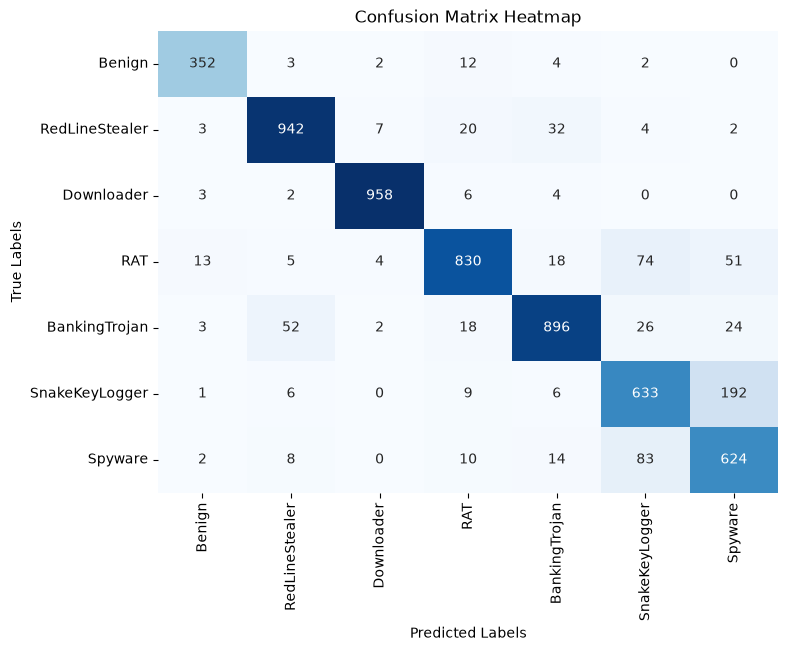

In [70]:
display_confusion_matrix(cf, class_names)

## 2.4 Try with ExtraTreesClassifier

In [71]:
from sklearn.ensemble import ExtraTreesClassifier

extra = ExtraTreesClassifier(
    n_estimators=500,
    criterion="entropy",
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

extra.fit(X_train, y_train)

y_pred_3 = extra.predict(X_test)



In [72]:
accuracy, f1, cf, precision, recall = calculate_metric(y_true=y_test, y_pred=y_pred_3)
results.append(accuracy)
f1_results.append(f1)
precision_results.append(precision)
recall_results.append(recall)
print(f'Accuracy: {accuracy:.4f}')

print(f'F1 scores: {f1:.4f}')

print(f'Confusion matrix: {cf}')

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

Accuracy: 0.8839
F1 scores: 0.8837
Confusion matrix: [[354   0   4  11   2   3   1]
 [  1 949   3  13  36   5   3]
 [  2   3 957   4   4   3   0]
 [  8   4   4 844  20  67  48]
 [  3  26   4  20 924  18  26]
 [  1   3   0  28   9 652 154]
 [  0   6   0  26  18 101 590]]
Precision: 0.8845
Recall   : 0.8838


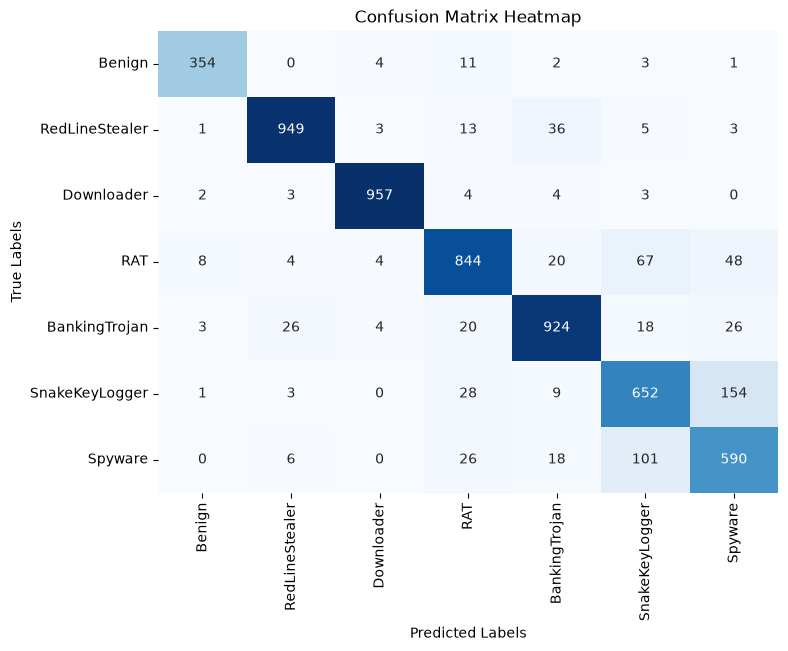

In [73]:
display_confusion_matrix(cf, class_names)

In [74]:
results, f1_results, precision_results, recall_results

([0.8879570613887957,
  0.8881247903388125,
  0.8780610533378062,
  0.8839315665883931],
 [0.8873378746299149,
  0.888430119978014,
  0.8777122597578898,
  0.8837480091753361],
 [0.886728095647159,
  0.8885434700741127,
  0.8785001002426254,
  0.8845113813551579],
 [0.8899533407493552,
  0.8891564527303705,
  0.8795877696178716,
  0.8837704690004619])

# 3. Let Visuzlize our a result

In [75]:
model_names = [
    "Random Forest",
	"XGBClassifier",
	"CastBoots",
    "Extra Trees",
]

# do a func for visualize metric

def Visualize_metric (list_name_model: [], list_metrics: [] ):

	plt.figure(figsize=(10, 6))

	plt.barh(list_name_model, list_metrics)

	plt.xlabel("Accuracy")
	plt.ylabel("Model")
	plt.title("Model Accuracy Comparison")

	plt.xlim(0, 1)

	for i, metric in enumerate(list_metrics):
		plt.text(
			metric + 0.01,
			i,
			f"{metric:.2%}",
			va="center"
		)

	plt.show()

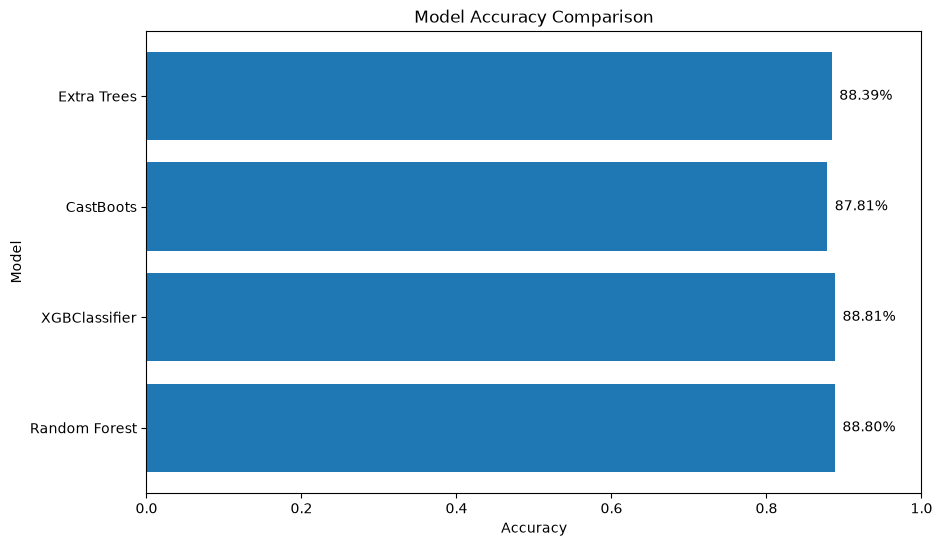

In [78]:
Visualize_metric(model_names, results)

# Conclusion

As you see that I have tried to four model, but the performance seem has not changed better, even I changed values of parameter.

Let's find out what happen with our data

In [79]:
df.groupby("Type")[
    [
        "TimeDateStamp",
        "AddressOfEntryPoint",
        "SizeOfImage",
        "SizeOfCode",
        "SizeOfInitializedData",
        "CheckSum",
        "DllCharacteristics",
        "MajorLinkerVersion",
        "Characteristics"
    ]
].mean()

,TimeDateStamp,AddressOfEntryPoint,SizeOfImage,SizeOfCode,SizeOfInitializedData,CheckSum,DllCharacteristics,MajorLinkerVersion,Characteristics
Type,,,,,,,,,
0,1.142691e+09,269010.173681,4.316970e+05,2.776696e+05,9.023584e+04,1.689780e+05,21290.416622,9.937134,596.784230
1,1.482472e+09,553160.835348,5.111583e+06,1.174967e+05,4.421502e+06,2.271336e+05,15743.830394,7.376659,680.466218
2,1.500302e+09,124470.568257,6.616017e+05,6.518329e+06,4.712357e+06,4.588777e+05,9800.447368,6.887747,364.137952
3,1.541205e+09,309382.479992,7.265075e+05,2.918202e+05,3.132738e+05,4.686688e+06,21806.881158,15.042228,4699.885783
4,1.903900e+09,824732.514694,3.227124e+06,4.068887e+05,2.073001e+06,1.104640e+06,31303.736677,19.959835,516.477077
5,1.907254e+09,614027.774788,7.431417e+05,6.095324e+05,9.626602e+04,4.537721e+04,33266.009443,42.505194,270.042257
6,1.904661e+09,623329.842148,7.022883e+05,6.137075e+05,5.084998e+04,3.624884e+04,32895.671883,41.125742,316.726659


In [81]:
features = [
    "TimeDateStamp",
    "AddressOfEntryPoint",
    "SizeOfImage",
    "SizeOfCode",
    "SizeOfInitializedData",
    "CheckSum",
    "DllCharacteristics",
    "MajorLinkerVersion",
    "Characteristics"
]

df[df["Type"].isin([ 5, 6])][
    ["Type"] + features
].groupby("Type").median()

,TimeDateStamp,AddressOfEntryPoint,SizeOfImage,SizeOfCode,SizeOfInitializedData,CheckSum,DllCharacteristics,MajorLinkerVersion,Characteristics
Type,,,,,,,,,
5,1.641908e+09,582536.0,655360.0,571392.0,12288.0,0.0,34112.0,48.0,258.0
6,1.650568e+09,632292.0,679936.0,622336.0,6144.0,0.0,34112.0,48.0,258.0
